In [21]:
# TUMOR TAIWAN VS TUMOR WHITE
# TUMOR WHITE VS TUMOR TAIWAN
# NORMAL TAIWAN VS NORMAL WHITE
# NORMAL WHITE VS NORMAL TAIWAN

In [22]:
library(WGCNA)
library(clusterProfiler)
library(ggplot2)

In [23]:
cohort <- "WHITEVSTAIWAN"
taiwan_wd = "/home/seba/github_repos/crc_weighted_network/taiwanese_cohort"
white_wd = "/home/seba/github_repos/crc_weighted_network/cohort_white"

if (cohort == "TAIWANVSWHITE") {
    config <- list(
        ref_tumor = paste0(taiwan_wd, "/rna_tumor"),
        ref_normal = paste0(taiwan_wd, "/rna_normal"),
        test_tumor = paste0(white_wd, "/rna_tumor"),
        test_normal = paste0(white_wd, "/rna_normal"),
        gene2mod = paste0(taiwan_wd, "/rna_tumor/module_membership_gene2module.tsv")
    )
} else if (cohort == "WHITEVSTAIWAN"){
    config <- list(
        ref_tumor = paste0(white_wd, "/rna_tumor"),
        ref_normal = paste0(white_wd, "/rna_normal"),
        test_tumor = paste0(taiwan_wd, "/rna_tumor"),
        test_normal = paste0(taiwan_wd, "/rna_normal"),
        gene2mod = paste0(white_wd, "/rna_tumor/module_membership_gene2module.tsv")
    )
} 

In [24]:
# tumoral vs tumoral y normal vs normal inter cohorte
ref_tumor <- readRDS(paste0(config$ref_tumor, "/datExpr_clean.rds"))
ref_normal <- readRDS(paste0(config$ref_normal, "/datExpr_clean.rds"))
test_tumor <- readRDS(paste0(config$test_tumor, "/datExpr_clean.rds"))
test_normal <- readRDS(paste0(config$test_normal, "/datExpr_clean.rds"))

In [25]:
commonGenes <- intersect(colnames(ref_tumor), colnames(test_tumor))

ref_tumor  <- ref_tumor[, commonGenes, drop=FALSE]
test_tumor <- test_tumor[, commonGenes, drop=FALSE]

In [26]:
gene2mod <- read.table(config$gene2mod, header=TRUE, stringsAsFactors=FALSE, sep="\t")
refColors_map <- setNames(gene2mod$module, gene2mod$gene)
refColors <- refColors_map[commonGenes]

In [27]:
multiExpr <- list(
  Ref  = list(data = ref_tumor),
  Test = list(data = test_tumor)
)

colorList <- list(Ref = refColors)

In [28]:
# Do this only if inter_module_preservation.rds does not exist
if (!file.exists(paste0(cohort, "_inter_tumor_module_preservation.rds"))) {
    mp <- modulePreservation(
    multiExpr, colorList,
    referenceNetworks = 1,
    networkType = "signed",
    corFnc = "bicor",     # or "cor" if Pearson
    nPermutations = 200,
    randomSeed = 1,
    verbose = 3
)
saveRDS(mp, file=paste0(cohort, "_inter_tumor_module_preservation.rds"))
} else {
    mp <- readRDS(paste0(cohort, "_inter_tumor_module_preservation.rds"))
}

In [29]:
Ztab  <- mp$preservation$Z$ref.Ref$inColumnsAlsoPresentIn.Test
Ztab <- as.data.frame(Ztab)

In [30]:
out <- data.frame(
  module = rownames(Ztab),
  size = Ztab$moduleSize,
  Zsummary_pres = Ztab$Zsummary.pres,
  Zdensity_pres = Ztab$Zdensity.pres,
  Zconnectivity_pres = Ztab$Zconnectivity.pres,
  stringsAsFactors = FALSE
)

out <- out[order(-out$Zsummary_pres), ]
head(out, 20)

,module,size,Zsummary_pres,Zdensity_pres,Zconnectivity_pres
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
2,blue,554,81.34153,149.64591,13.037145
45,yellow,554,80.55080,129.73133,31.370266
42,turquoise,1000,58.68755,76.88523,40.489879
24,magenta,322,57.98163,93.19977,22.763494
33,red,476,46.65628,67.01714,26.295429
26,midnightblue,134,40.76219,68.50372,13.020661
4,cyan,130,39.07749,65.87239,12.282589
30,pink,371,35.97545,50.76691,21.183982
27,orange,68,34.72433,62.80150,6.647151


In [31]:
svg(paste0(cohort, "_inter_tumor_module_preservation_1.svg"))
ggplot(out, aes(x = size, y = Zsummary_pres, color = module, label = module)) +
  geom_point(size = 3) +
  geom_text(vjust = -0.7, size = 3, show.legend = FALSE) +
  geom_hline(yintercept = c(2, 10),
             linetype = "dashed",
             color = "grey40") +
  scale_color_identity() +
  labs(
    x = "Module size (# genes)",
    y = "Zsummary (preservation)",
    title = "Module preservation (reference → test)"
  ) +
  theme_bw()
dev.off()

pdf 
  2

In [32]:
svg(paste0(cohort, "_inter_tumor_module_preservation_2.svg"))
ggplot(out, aes(x = Zdensity_pres, y = Zconnectivity_pres,
                color = module, label = module)) +
  geom_point(size = 3) +
  geom_text(vjust = -0.7, size = 3, show.legend = FALSE) +
  geom_vline(xintercept = 2,
             linetype = "dashed",
             color = "grey40") +
  geom_hline(yintercept = 2,
             linetype = "dashed",
             color = "grey40") +
  scale_color_identity() +
  labs(
    x = "Zdensity (preservation)",
    y = "Zconnectivity (preservation)",
    title = "Preservation components"
  ) +
  theme_bw()
dev.off()


pdf 
  2

In [33]:
commonGenes <- intersect(colnames(ref_normal), colnames(test_normal))

ref_normal  <- ref_normal[, commonGenes, drop=FALSE]
test_normal <- test_normal[, commonGenes, drop=FALSE]

In [34]:
refColors_map <- setNames(gene2mod$module, gene2mod$gene)
refColors <- refColors_map[commonGenes]

In [35]:
multiExpr <- list(
    Ref = list(data = ref_normal),
    Test  = list(data = test_normal)
)

colorList <- list(Ref = refColors)

In [36]:
# Do this only if inter_module_preservation_white_tumor_vs_taiwan_tumor.rds does not exist
if (!file.exists(paste0(cohort, "_inter_normal_module_preservation.rds"))){
    mp <- modulePreservation(
    multiExpr, colorList,
    referenceNetworks = 1,
    networkType = "signed",
    corFnc = "bicor",     # or "cor" if Pearson
    nPermutations = 200,
    randomSeed = 1,
    verbose = 3
)
saveRDS(mp, file=paste0(cohort, "_inter_normal_module_preservation.rds"))
} else {
    mp <- readRDS(paste0(cohort, "_inter_normal_module_preservation.rds"))
}

In [37]:
Ztab  <- mp$preservation$Z$ref.Ref$inColumnsAlsoPresentIn.Test
Ztab <- as.data.frame(Ztab)

In [38]:
out <- data.frame(
  module = rownames(Ztab),
  size = Ztab$moduleSize,
  Zsummary_pres = Ztab$Zsummary.pres,
  Zdensity_pres = Ztab$Zdensity.pres,
  Zconnectivity_pres = Ztab$Zconnectivity.pres,
  stringsAsFactors = FALSE
)

out <- out[order(-out$Zsummary_pres), ]
head(out, 20)

,module,size,Zsummary_pres,Zdensity_pres,Zconnectivity_pres
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
3,brown,1000,53.611063,91.31960,15.902527
2,blue,554,48.318231,81.62063,15.015831
15,greenyellow,259,36.034104,68.96164,3.106563
33,red,476,31.618154,53.60165,9.634656
36,salmon,142,25.401636,47.45439,3.348883
45,yellow,554,24.166946,21.17296,27.160927
6,darkgrey,92,21.595525,32.39547,10.795582
30,pink,371,18.857392,27.88368,9.831103
44,white,55,18.817730,35.38068,2.254775


In [39]:
svg(paste0(cohort, "_inter_normal_module_preservation_1.svg"))
ggplot(out, aes(x = size, y = Zsummary_pres, color = module, label = module)) +
  geom_point(size = 3) +
  geom_text(vjust = -0.7, size = 3, show.legend = FALSE) +
  geom_hline(yintercept = c(2, 10),
             linetype = "dashed",
             color = "grey40") +
  scale_color_identity() +
  labs(
    x = "Module size (# genes)",
    y = "Zsummary (preservation)",
    title = "Module preservation (reference → test)"
  ) +
  theme_bw()
dev.off()

pdf 
  2

In [40]:
svg(paste0(cohort, "_inter_normal_module_preservation_2.svg"))
ggplot(out, aes(x = Zdensity_pres, y = Zconnectivity_pres,
                color = module, label = module)) +
  geom_point(size = 3) +
  geom_text(vjust = -0.7, size = 3, show.legend = FALSE) +
  geom_vline(xintercept = 2,
             linetype = "dashed",
             color = "grey40") +
  geom_hline(yintercept = 2,
             linetype = "dashed",
             color = "grey40") +
  scale_color_identity() +
  labs(
    x = "Zdensity (preservation)",
    y = "Zconnectivity (preservation)",
    title = "Preservation components"
  ) +
  theme_bw()
dev.off()


pdf 
  2

In [41]:
# Analisis de preservacion entre las redes globales (coexpresion RNA tumor y normal a la vez)
if (cohort == "TAIWANVSWHITE"){
    config <- list(
        ref_expr = paste0(taiwan_wd, "/rna_pooled_tmm"),
        test_expr = paste0(white_wd, "/2_RNA_TMM_T_merged_counts"),
        gene2mod = paste0(taiwan_wd, "/rna_pooled_tmm/module_membership_gene2module.tsv")
    )
} else if (cohort == "WHITEVSTAIWAN"){
    config <- list(
        ref_expr = paste0(white_wd, "/2_RNA_TMM_T_merged_counts"),
        test_expr = paste0(taiwan_wd, "/rna_pooled_tmm"),
        gene2mod = paste0(white_wd, "/2_RNA_TMM_T_merged_counts/module_membership_gene2module.tsv")
    )
}

In [42]:
ref_expr <- readRDS(paste0(config$ref_expr, "/datExpr_clean.rds"))
test_expr <- readRDS(paste0(config$test_expr, "/datExpr_clean.rds"))

commonGenes <- intersect(colnames(ref_expr), colnames(test_expr))

ref_expr  <- ref_expr[, commonGenes, drop=FALSE]
test_expr <- test_expr[, commonGenes, drop=FALSE]

In [43]:
gene2mod <- read.table(config$gene2mod, header=TRUE, stringsAsFactors=FALSE, sep="\t")
refColors_map <- setNames(gene2mod$module, gene2mod$gene)
refColors <- refColors_map[commonGenes]

In [44]:
multiExpr <- list(
  Ref  = list(data = ref_expr),
  Test = list(data = test_expr)
)

colorList <- list(Ref = refColors)

In [45]:
if (!file.exists(paste0(cohort, "_inter_module_preservation_GLOBAL.rds"))){
    mp <- modulePreservation(
    multiExpr, colorList,
    referenceNetworks = 1,
    networkType = "signed",
    corFnc = "bicor",     # or "cor" if Pearson
    nPermutations = 200,    
    randomSeed = 1,
    verbose = 3
)
saveRDS(mp, file=paste0(cohort, "_inter_module_preservation_GLOBAL.rds"))
} else {
    mp <- readRDS(paste0(cohort, "_inter_module_preservation_GLOBAL.rds"))
}

In [46]:
Ztab  <- mp$preservation$Z$ref.Ref$inColumnsAlsoPresentIn.Test
Ztab <- as.data.frame(Ztab)

In [47]:
out <- data.frame(
  module = rownames(Ztab),
  size = Ztab$moduleSize,
  Zsummary_pres = Ztab$Zsummary.pres,
  Zdensity_pres = Ztab$Zdensity.pres,
  Zconnectivity_pres = Ztab$Zconnectivity.pres,
  stringsAsFactors = FALSE
)

out <- out[order(-out$Zsummary_pres), ]
head(out, 20)

,module,size,Zsummary_pres,Zdensity_pres,Zconnectivity_pres
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
3,brown,1000,41.562203,53.8029993,29.321406
17,turquoise,1000,32.490479,35.4923766,29.488580
14,red,501,30.625893,41.3340320,19.917755
5,gold,1000,23.020332,13.0088719,33.031791
1,black,396,20.482292,15.4724722,25.492112
18,yellow,543,17.974476,21.8040196,14.144933
13,purple,234,16.684885,26.8235372,6.546233
4,cyan,97,15.180126,24.9536376,5.406615
12,pink,394,15.040041,12.8701454,17.209937


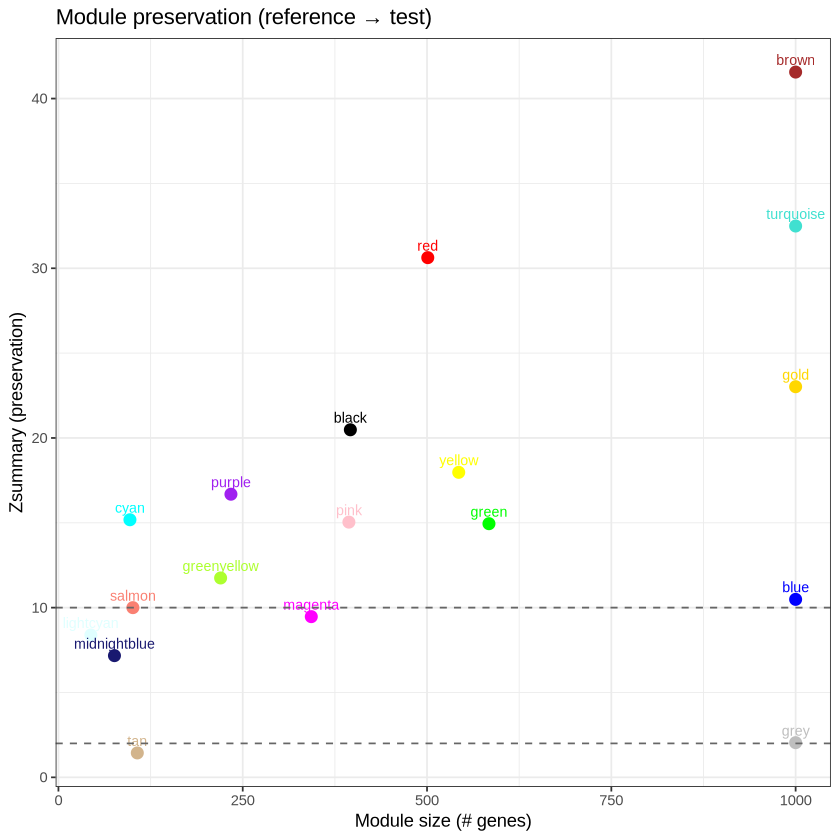

In [48]:
ggplot(out, aes(x = size, y = Zsummary_pres, color = module, label = module)) +
  geom_point(size = 3) +
  geom_text(vjust = -0.7, size = 3, show.legend = FALSE) +
  geom_hline(yintercept = c(2, 10),
             linetype = "dashed",
             color = "grey40") +
  scale_color_identity() +
  labs(
    x = "Module size (# genes)",
    y = "Zsummary (preservation)",
    title = "Module preservation (reference → test)"
  ) +
  theme_bw()

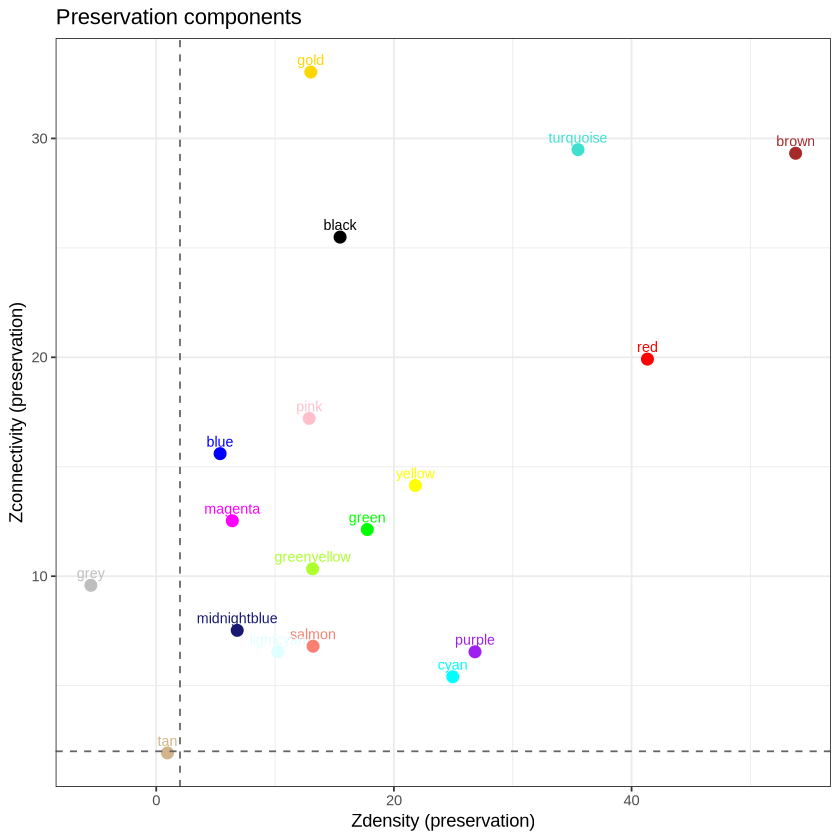

In [49]:
ggplot(out, aes(x = Zdensity_pres, y = Zconnectivity_pres,
                color = module, label = module)) +
  geom_point(size = 3) +
  geom_text(vjust = -0.7, size = 3, show.legend = FALSE) +
  geom_vline(xintercept = 2,
             linetype = "dashed",
             color = "grey40") +
  geom_hline(yintercept = 2,
             linetype = "dashed",
             color = "grey40") +
  scale_color_identity() +
  labs(
    x = "Zdensity (preservation)",
    y = "Zconnectivity (preservation)",
    title = "Preservation components"
  ) +
  theme_bw()
